R2 score = 22.19%
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=4, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=4, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=4, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=4, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=4, model__n_estimators=100,

<Axes: >

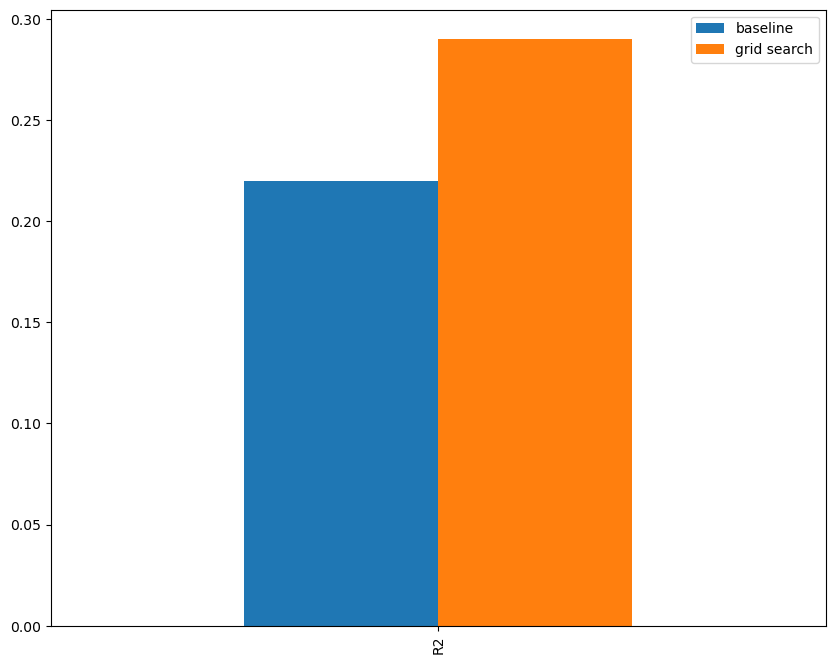

In [17]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score 

# Evaluate predictions 
def evaluate_preds(y_true, y_preds):
    r2 = r2_score(y_true, y_preds)
    mae = mean_absolute_error(y_true, y_preds)
    print(f"R2 score = {r2*100:.2f}%")

    metric_dict = {
      "R2" : np.round(r2, 2),
    }

    return metric_dict


# Get data
data = pd.read_csv("./data/car-sales-extended-missing-data.csv")
data.dropna(subset=["Price"], inplace=True)
np.random.seed(42)

# Check the count of missing values
data.isna().sum()

# Get data ready
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = ["Make", "Colour"]
numerical_features = ["Odometer (KM)"]
door_features = ["Doors"]

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

door_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=4))
])

numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])


preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_features),
    ("door", door_transformer, door_features),
    ("num", numerical_transformer, numerical_features)
], remainder="passthrough")

# Create a model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

# Split data
X = data.drop("Price", axis=1)
y = data["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

y_preds = model.predict(X_test)

baseline_metric_dict = evaluate_preds(y_test, y_preds)

grid = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "model__n_estimators": [100, 200],
    "model__max_depth": [5],
    "model__max_features": ["sqrt"],
    "model__min_samples_split": [4],
    "model__min_samples_leaf": [2, 4],
}

gs_reg = GridSearchCV(model, param_grid=grid, n_jobs=1, cv=5, verbose=2)
gs_reg.fit(X_train, y_train)
gs_y_preds = gs_reg.predict(X_test)
gs_metric_dict = evaluate_preds(y_test, gs_y_preds)

metrics_df = pd.DataFrame({
    "baseline": baseline_metric_dict,
    "grid search": gs_metric_dict
})

metrics_df.plot(figsize = (10, 8), kind = "bar")

In [19]:
from joblib import dump, load
dump(gs_reg, filename="./model/car_sales_random_forest_model.joblib")

['./model/car_sales_random_forest_model.joblib']